In [1]:
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
# Parameters
f0 = 10    
fs = 100        
T1 = 1.00     
T2 = 0.95    

# Generate signals
t1 = np.arange(0, T1, 1/fs)
x1 = np.sin(2 * np.pi * f0 * t1)

t2 = np.arange(0, T2, 1/fs)
x2 = np.sin(2 * np.pi * f0 * t2)

In [ ]:
# User-defined DFT (fully manual, no np.fft)
def one_sided_dft(x, fs):
    n = len(x)
    X = np.zeros(n, dtype=complex)

    for k in range(n):
        s = 0j
        for m in range(n):
            angle = -2j * np.pi * k * m / n
            s += x[m] * np.exp(angle)
        X[k] = s

    # Manual frequency bins equivalent to fftfreq
    f = np.zeros(n)
    for k in range(n):
        if k <= n // 2:
            f[k] = k * fs / n
        else:
            f[k] = (k - n) * fs / n

    mag = np.abs(X) / n
    return f, mag

In [ ]:
# Compute one-sided DFT (frequency and magnitude)
def one_sided_DFT(x, fs):
    n = len(x)
    f = np.fft.fftfreq(n, 1 / fs)
    mag = np.abs(np.fft.fft(x)) / n
    return f, mag 

In [4]:
# DFT for both durations
f1, mag1 = one_sided_dft(x1, fs)
f2, mag2 = one_sided_dft(x2, fs)

# Apply Hamming window to 0.95 s signal
w = np.hamming(len(x2))
x2_win = x2 * w
f2w, mag2w = one_sided_dft(x2_win, fs)

# Normalize windowed spectrum so peak-height comparison is fair
mag2w = mag2w / (np.mean(w))

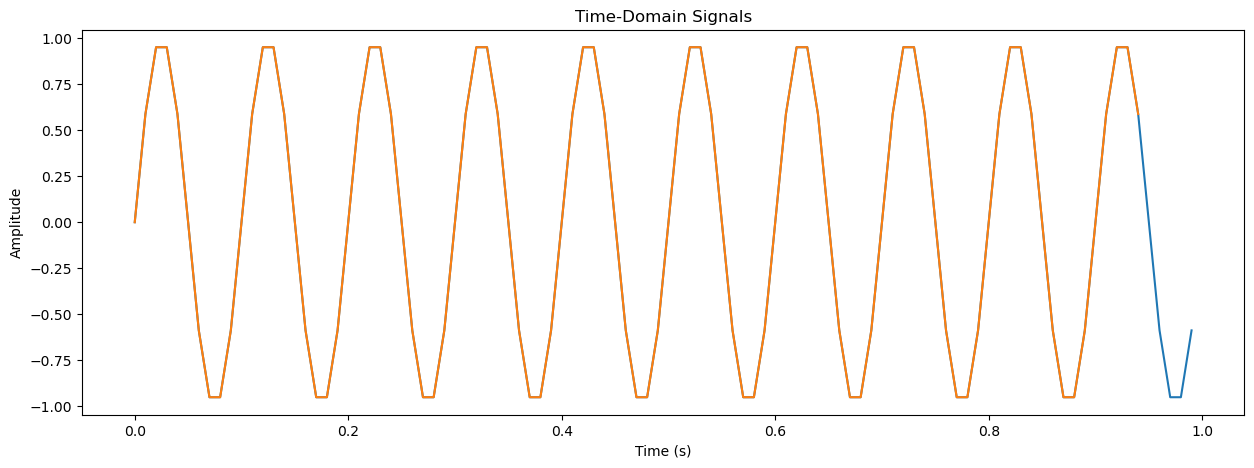

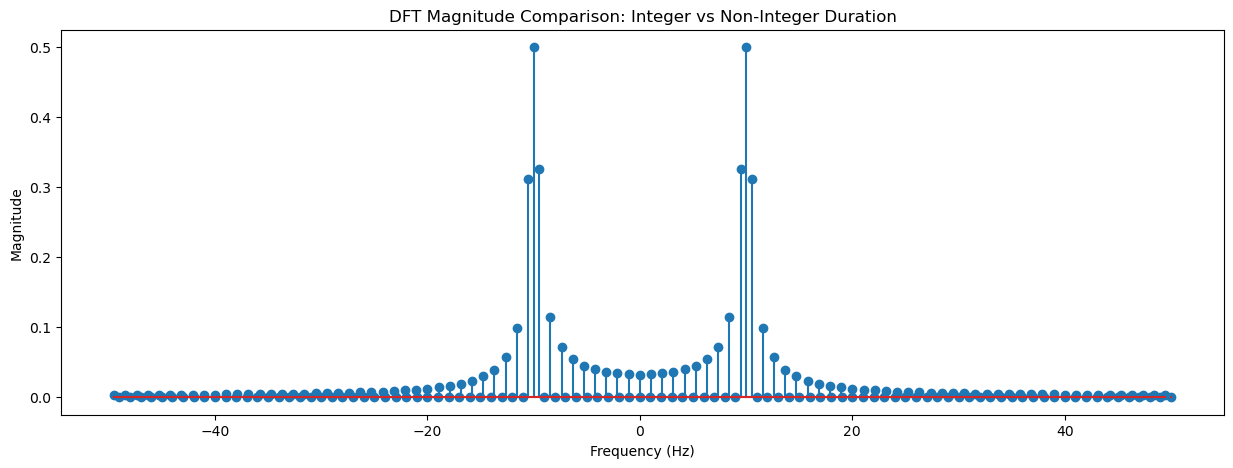

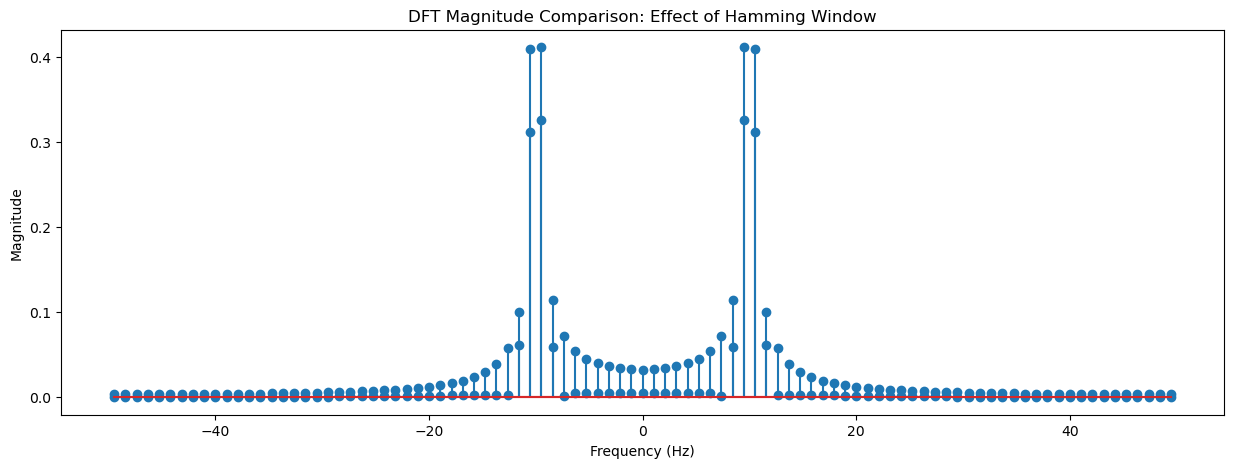

In [5]:
# Plot time-domain signals
plt.figure(figsize=(15, 5))
plt.plot(t1, x1)
plt.plot(t2, x2)
plt.title('Time-Domain Signals')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

# Compare spectra: integer-cycle vs non-integer-cycle
plt.figure(figsize=(15, 5))
plt.stem(f1, mag1)
plt.stem(f2, mag2)
plt.title('DFT Magnitude Comparison: Integer vs Non-Integer Duration')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.show()

# Compare spectra for 0.95 s: before vs after Hamming window
plt.figure(figsize=(15, 5))
plt.stem(f2, mag2)
plt.stem(f2w, mag2w)
plt.title('DFT Magnitude Comparison: Effect of Hamming Window')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.show()


In [6]:
# Simple numerical summary of dominant frequency
peak1 = f1[np.argmax(mag1)]
peak2 = f2[np.argmax(mag2)]
peak2w = f2w[np.argmax(mag2w)]

print(f'Peak frequency (1.00 s): {peak1:.2f} Hz')
print(f'Peak frequency (0.95 s, no window): {peak2:.2f} Hz')
print(f'Peak frequency (0.95 s, Hamming): {peak2w:.2f} Hz')

Peak frequency (1.00 s): -10.00 Hz
Peak frequency (0.95 s, no window): -9.47 Hz
Peak frequency (0.95 s, Hamming): -9.47 Hz
